# Love Waves Theory

 > **Colab note:** This notebook is designed to run on **Google Colab**. The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UW-geophysics-edu/ess-412-512-intro2seismology/blob/main/notebooks/05b_Love_Waves_Theory.ipynb)

**Learning Objectives:**
- Derive Love wave dispersion relation for a layer over half-space
- Understand the constructive interference mechanism
- Calculate phase and group velocities
- Visualize mode shapes vs depth

**Prerequisites:** Wave equation, Eigenvalue problems

**Reference:** Shearer, Chapter 8 (Surface Waves)

**Notebook Outline:**
- [1. Ray picture](#1-Ray-picture)
- [2. Admissible velocities and trapping condition](#2-Admissible-velocities-and-trapping-condition)
- [3. Dispersion equation (eigencondition)](#3-Dispersion-equation-eigencondition)
- [4. Root finding in phase velocity](#4-Root-finding-in-phase-velocity)
- [5. Dispersion curves and group velocity](#5-Dispersion-curves-and-group-velocity)
- [6. Eigenfunctions (mode shapes)](#6-Eigenfunctions-mode-shapes)
- [7. Toy seismogram: dispersion → wavetrain](#7-Toy-seismogram-dispersion-→-wavetrain)
- [8. Conceptual takeaway](#8-Conceptual-takeaway)

---
a low-velocity layer (β1, ρ1, thickness H) over a faster half-space (β2, ρ2).



In [ ]:
# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'scipy': 'scipy',
    'obspy': 'obspy'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ---- Model parameters (editable)
H_km = 20.0        # layer thickness (km)
beta1 = 3.2        # km/s (layer)
beta2 = 4.0        # km/s (half-space), must be > beta1
rho1 = 2800.0      # kg/m^3
rho2 = 3300.0      # kg/m^3

mu1 = rho1 * (beta1*1000)**2  # Pa (convert km/s to m/s)
mu2 = rho2 * (beta2*1000)**2

H = H_km * 1000.0  # m

assert beta2 > beta1, "Need beta2 > beta1 for guided Love waves in this model."


## 1. Ray picture  
Love waves can be viewed as constructive interference of SH surface multiples (S, SS, SSS, ...).
- Phase velocity: $(c = \omega/k)$ controls motion of peaks/troughs.
- Group velocity: $(U = d\omega/dk)$ controls energy/envelope propagation.

**Prediction questions (answer before computing):**
1) Will Love waves be dispersive in this model? Why?
2) Is \(U\) typically less than \(c\) for normal Earth-like dispersion?
3) How will higher modes differ from the fundamental mode?


## 2. Admissible velocities and trapping condition
For guided Love waves in a layer over half-space:
- The phase velocity must satisfy \( \beta_1 < c < \beta_2 \).
- In the layer, SH is oscillatory in depth.
- In the half-space, SH must be evanescent (decay with depth).

We will enforce trapping by requiring the half-space vertical wavenumber to be real and positive decay.


In [2]:
def admissible_c(c):
    return (c > beta1) and (c < beta2)


## 3. Dispersion equation (eigencondition)
We solve for $c$ at each angular frequency $\omega$.
Let $k = \omega/c$. Define vertical wavenumbers:

Layer (oscillatory):
$$ q_1 = \sqrt{\omega^2/\beta_1^2 - k^2} $$
Half-space (evanescent):
$$ \kappa_2 = \sqrt{k^2 - \omega^2/\beta_2^2}$$

The Love-wave eigencondition is:
$$ \tan(q_1 H) = \frac{\mu_2\,\kappa_2}{\mu_1\,q_1}.
$$

**Interpretation:** non-trivial solutions exist only for discrete $c(\omega)$ values (modes).


In [3]:
def love_dispersion_F(c, omega, H, beta1, beta2, mu1, mu2):
    """
    F(c; omega) = tan(q1 H) - (mu2*kappa2)/(mu1*q1)
    Root(s) in c give Love-wave modes at frequency omega.
    """
    if not (beta1 < c < beta2):
        return np.nan

    k = omega / c

    q1_sq = (omega/beta1)**2 - k**2
    kappa2_sq = k**2 - (omega/beta2)**2

    # Trapping: q1^2 > 0 (oscillatory in layer), kappa2^2 > 0 (evanescent in half-space)
    if (q1_sq <= 0) or (kappa2_sq <= 0):
        return np.nan

    q1 = np.sqrt(q1_sq)
    kappa2 = np.sqrt(kappa2_sq)

    return np.tan(q1 * H) - (mu2 * kappa2) / (mu1 * q1)


## 4. Root finding in phase velocity
At each period T (or frequency ω), solve F(c; ω)=0 in the interval (β1, β2).

Because tan() introduces multiple branches, there can be multiple roots:
- fundamental mode (lowest root in ω–c sense),
- higher modes (overtones).

We will:
1) define a frequency (period) grid,
2) bracket roots in c,
3) store multiple modes per ω (as available).


In [4]:
# Period grid (seconds): adjust for classroom pace
T = np.linspace(5, 80, 120)      # s
omega = 2*np.pi / T              # rad/s

# Root bracketing grid in c
c_grid = np.linspace(beta1*1.001, beta2*0.999, 2000)

def find_roots_for_omega(om, max_modes=4):
    Fvals = []
    for c in c_grid:
        Fvals.append(love_dispersion_F(c, om, H, beta1, beta2, mu1, mu2))
    Fvals = np.array(Fvals, dtype=float)

    roots = []
    # find sign changes (ignore NaNs)
    for i in range(len(c_grid)-1):
        f1, f2 = Fvals[i], Fvals[i+1]
        if np.isnan(f1) or np.isnan(f2):
            continue
        if f1 == 0:
            roots.append(c_grid[i])
        if f1*f2 < 0:
            a, b = c_grid[i], c_grid[i+1]
            try:
                r = brentq(love_dispersion_F, a, b, args=(om, H, beta1, beta2, mu1, mu2), maxiter=200)
                roots.append(r)
            except ValueError:
                pass
        if len(roots) >= max_modes:
            break
    return np.array(sorted(set(np.round(roots, 10))))

# Compute up to M modes
M = 4
c_modes = np.full((M, len(omega)), np.nan)

for j, om in enumerate(omega):
    roots = find_roots_for_omega(om, max_modes=M)
    for m in range(min(M, len(roots))):
        c_modes[m, j] = roots[m]


## 5. Dispersion curves and group velocity
Plot phase velocity c(T) for multiple modes.

Compute group velocity from:
$$
U = \frac{d\omega}{dk}, \quad k=\omega/c(\omega).
$$
Numerically, compute k(ω) then differentiate.


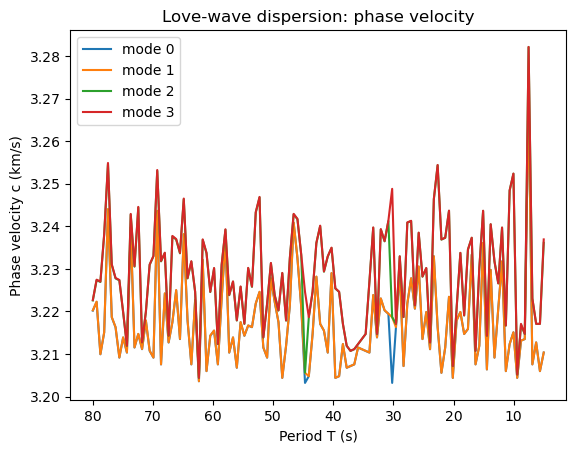

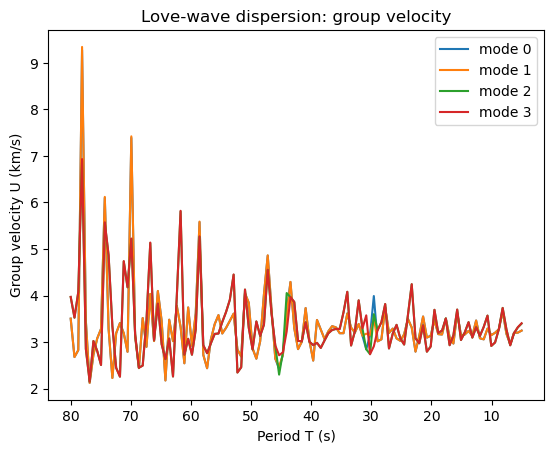

In [5]:
plt.figure()
for m in range(M):
    plt.plot(T, c_modes[m], label=f"mode {m}")
plt.gca().invert_xaxis()  # optional: long period to the left
plt.xlabel("Period T (s)")
plt.ylabel("Phase velocity c (km/s)")
plt.title("Love-wave dispersion: phase velocity")
plt.legend()
plt.show()

# Group velocity estimate per mode
U_modes = np.full_like(c_modes, np.nan)
for m in range(M):
    c = c_modes[m].copy()
    valid = np.isfinite(c)
    if np.sum(valid) < 5:
        continue
    om = omega[valid]
    k = om / c[valid]  # (rad/s)/(km/s) = rad/km
    # numerical derivative: U = dω/dk
    domega = np.gradient(om)
    dk = np.gradient(k)
    U = domega / dk
    U_modes[m, valid] = U

plt.figure()
for m in range(M):
    plt.plot(T, U_modes[m], label=f"mode {m}")
plt.gca().invert_xaxis()
plt.xlabel("Period T (s)")
plt.ylabel("Group velocity U (km/s)")
plt.title("Love-wave dispersion: group velocity")
plt.legend()
plt.show()


## 6. Eigenfunctions (mode shapes)
For a chosen period T*, and a chosen mode m:
- In the layer (0 ≤ z ≤ H): u1(z) = A cos(q1 z) + B sin(q1 z)
- In the half-space (z ≥ H): u2(z) = C exp(-κ2 (z-H))

Apply:
1) free surface traction σ_yz = 0 at z=0 → du/dz = 0 at z=0
2) continuity of u at z=H
3) continuity of traction μ du/dz at z=H

We will compute a normalized mode shape and plot u(z).


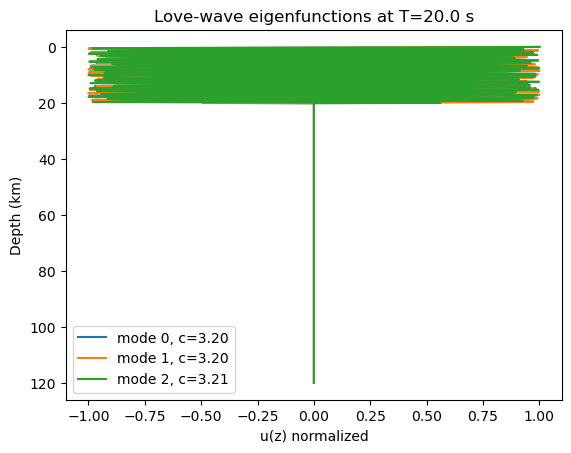

In [6]:
def love_mode_shape(T_star, mode_index=0, zmax_km=100.0, nz=800):
    om = 2*np.pi / T_star
    c = c_modes[mode_index, np.argmin(np.abs(T - T_star))]
    if not np.isfinite(c):
        raise ValueError("No mode available at this period for the selected mode index.")

    k = om / c
    q1 = np.sqrt((om/beta1)**2 - k**2)
    kappa2 = np.sqrt(k**2 - (om/beta2)**2)

    # From free-surface traction: du/dz(0)=0 ⇒ B=0 if we choose cos form
    # Use u1(z) = A cos(q1 z)
    A = 1.0

    # Match at z=H:
    # u1(H) = C
    # μ1 u1'(H) = μ2 u2'(H) with u2(z)=C exp(-kappa2(z-H)) ⇒ u2'(H) = -kappa2 C
    uH = A*np.cos(q1*H)
    du1H = -A*q1*np.sin(q1*H)

    # traction continuity: μ1 du1H = μ2 (-kappa2 C) = μ2 (-kappa2 uH)
    # In exact arithmetic this holds if c is a true root; we can still build shape with C=uH.
    C = uH

    z = np.linspace(0, zmax_km*1000, nz)
    u = np.zeros_like(z)

    in_layer = z <= H
    in_half = z > H

    u[in_layer] = A*np.cos(q1*z[in_layer])
    u[in_half] = C*np.exp(-kappa2*(z[in_half]-H))

    # normalize by surface amplitude
    u = u / u[0]
    return z/1000.0, u, c

# Example: choose a period and plot first few modes
T_star = 20.0
plt.figure()
for m in range(min(3, M)):
    try:
        z_km, u, c_here = love_mode_shape(T_star, mode_index=m, zmax_km=120)
        plt.plot(u, z_km, label=f"mode {m}, c={c_here:.2f}")
    except Exception:
        pass
plt.gca().invert_yaxis()
plt.xlabel("u(z) normalized")
plt.ylabel("Depth (km)")
plt.title(f"Love-wave eigenfunctions at T={T_star:.1f} s")
plt.legend()
plt.show()


## 7. Toy seismogram: dispersion → wavetrain
We synthesize a dispersive wave packet at distance x by summing frequencies with:
$$
u(x,t) = \Re \left\{ \int A(\omega)\, e^{i(k(\omega)x - \omega t)} d\omega \right\}
$$
where k(ω)=ω/c(ω). The envelope arrival is controlled by group velocity U.

We will:
1) pick a smooth amplitude spectrum A(ω),
2) use the fundamental-mode k(ω),
3) compute u(t) at a fixed x,
4) optionally compare predicted arrival times using U.


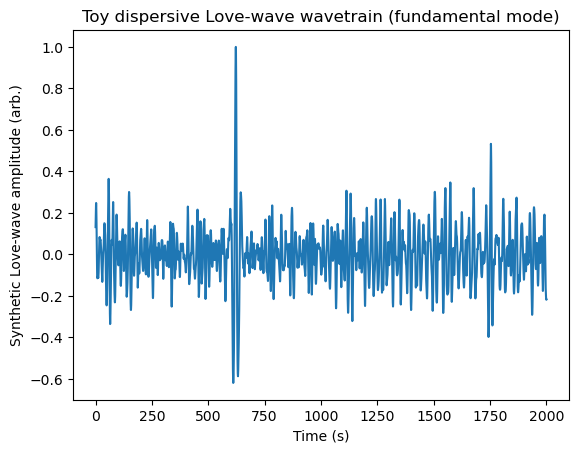

In [7]:
# Build a toy wavetrain for the fundamental mode (m=0)
m = 0
valid = np.isfinite(c_modes[m])
T_use = T[valid]
om_use = omega[valid]
c_use = c_modes[m, valid]
k_use = om_use / c_use  # rad/km

# Choose a Gaussian amplitude spectrum centered at T0
T0 = 20.0
sigmaT = 8.0
A = np.exp(-0.5*((T_use - T0)/sigmaT)**2)

# Distance and time axis
x_km = 2000.0
t = np.linspace(0, 2000, 4000)  # seconds

# Sum cosines (discrete integral)
u = np.zeros_like(t)
for Aj, kj, omj in zip(A, k_use, om_use):
    u += Aj*np.cos(kj*x_km - omj*t)

# Normalize and plot
u /= np.max(np.abs(u))

plt.figure()
plt.plot(t, u)
plt.xlabel("Time (s)")
plt.ylabel("Synthetic Love-wave amplitude (arb.)")
plt.title("Toy dispersive Love-wave wavetrain (fundamental mode)")
plt.show()


## 8. Conceptual takeaway
- The **same** Love wave can be understood as:
  1) constructive interference of SH multiples (ray picture),
  2) a trapped guided SH wave (boundary-value picture),
  3) an eigenmode selected by BCs (eigenvalue picture).

- Dispersion arises because the model contains a length scale (H) and depth-dependent sampling:
  longer periods sample deeper, faster structure.

**Exit question:**
How would each of the three pictures explain why higher modes exist?
